<a href="https://colab.research.google.com/github/fathinahnj/skripsi/blob/main/waste_classification_skripsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [1]:
%%capture
!pip install roboflow

In [2]:
%%capture
!pip install -q inference-gpu
!pip install -q trackers[sort]
!pip install -q supervision==0.27.0

In [3]:
%%capture
!pip install sympy
!pip install torch torchvision

In [4]:
%%capture
!pip install --upgrade ultralytics

In [5]:
%%capture
!pip install deep-sort-realtime
!pip install opencv-python
!pip install numpy

# Dataset

In [6]:
%%capture
from roboflow import Roboflow
rf = Roboflow(api_key="Wi7nmEb34BK9rtJ1O27x")
project = rf.workspace("organic-an-organic").project("river-waste-classification-saya")
version = project.version(5)
dataset = version.download("yolov8")


# Load model

In [8]:
model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")  # load a custom model

# Train

In [8]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train the model on the COCO8 example dataset for 100 epochs
# results = model.train(data='/content/River-Waste-Classification-Saya-5/data.yaml', epochs=250, imgsz=640)

# Val

In [7]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolov8n.pt")  # load an official model
model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val(data='/content/River-Waste-Classification-Saya-5/data.yaml')  # Specify the correct data.yaml path
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list containing mAP50-95 for each category

val: Scanning /content/River-Waste-Classification-Saya-5/valid/labels... 94 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 94/94 1.3Kit/s 0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1it/s 5.7s


array([    0.49907,      0.5971])

# Save Model

In [7]:
#%cp -r '/content/runs (v3.2)' /content/drive/MyDrive/SKRIPSI

In [8]:
%cd /content/drive/MyDrive/SKRIPSI
%ls

/content/drive/MyDrive/SKRIPSI
 dataset_crop_1to1/         hasil_video2/        'runs (v3)'/
 dataset_crop_1to1_part2/  'null images (raw)'/  'runs (v3.2)'/
'dataset dari wina'/        runs/                'sungai saddang.mp4'
 hasil_video/              'runs (v2)'/          'sungai tallo tol.mp4'


# Predict

In [10]:
from ultralytics import YOLO

YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [11]:
%%capture
model.predict(
    source="/content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4",   # video dari drive
    save=True,
    project="/content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video",     # folder output di drive
    conf=0.45,
    stream=False
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 1 Non-Plastic, 2 Plastics, 39.8ms
video 1/1 (frame 2/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 1 Non-Plastic, 3 Plastics, 10.6ms
video 1/1 (frame 3/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 2 Non-Plastics, 3 Plastics, 9.6ms
video 1/1 (frame 4/1376) /content/d

# Track Object

In [9]:
import cv2
import numpy as np
from deep_sort_realtime.deepsort_tracker import DeepSort

In [10]:
model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")

tracker = DeepSort(
    max_age=30,
    n_init=3,
    max_cosine_distance=0.4
)

In [12]:
%cd /content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video
%ls

/content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video
 predict/    predict3/  'Recording 2026-02-13 115518.avi'
 predict2/   predict4/


## chatgpt

In [13]:
cap = cv2.VideoCapture("/predict4/DJI_20260217145424_0015_D.avi")
# cap = cv2.VideoCapture(0)

In [14]:
while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r

        if conf > 0.5:
            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        track_id = track.track_id
        l, t, r, b = track.to_ltrb()

        x1 = int(l)
        y1 = int(t)
        x2 = int(r)
        y2 = int(b)

        cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)

        cv2.putText(
            frame,
            f"ID {track_id}",
            (x1,y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    cv2.imshow("Tracking", frame)

    if cv2.waitKey(1) == 27:
        break


In [16]:
cap.release()
cv2.destroyAllWindows()

In [18]:
from google.colab.patches import cv2_imshow
import time

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r

        if conf > 0.5:
            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        l, t, r, b = track.to_ltrb()

        cv2.rectangle(frame,
                      (int(l), int(t)),
                      (int(r), int(b)),
                      (0,255,0),2)

    cv2_imshow(frame)
    time.sleep(0.03)

In [19]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    'tracking_output.mp4',
    fourcc,
    30,
    (640, 480)
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r

        if conf > 0.5:
            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        l, t, r, b = track.to_ltrb()

        cv2.rectangle(frame,
                      (int(l), int(t)),
                      (int(r), int(b)),
                      (0,255,0),2)

    out.write(frame)

cap.release()
out.release()

## [docs orang](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-track-objects-with-deepsort-tracker.ipynb#scrollTo=oEhdLaeaJm1k)

In [17]:
from inference import get_model
from trackers import DeepSORTFeatureExtractor, DeepSORTTracker

model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")

feature_extractor = DeepSORTFeatureExtractor.from_timm(
    model_name="mobilenetv4_conv_small.e1200_r224_in1k")

tracker = DeepSORTTracker(feature_extractor=feature_extractor)

ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.


ImportError: cannot import name 'DeepSORTFeatureExtractor' from 'trackers' (/usr/local/lib/python3.12/dist-packages/trackers/__init__.py)

In [22]:
CONFIDENCE_THRESHOLD = 0.3
NMS_THRESHOLD = 0.3

SOURCE_VIDEO_PATH = "/content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4"
TARGET_VIDEO_PATH = "/content/drive/MyDrive/SKRIPSI/hasil_video/tracking"

In [33]:
import supervision as sv

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

box_annotator = sv.BoxAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK)

trace_annotator = sv.TraceAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK,
    thickness=2,
    trace_length=100)

label_annotator = sv.LabelAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK,
    text_color=sv.Color.BLACK,
    text_scale=0.8)

In [42]:
frame_samples = []

def callback(frame, i):
    result = model.infer(frame, confidence=CONFIDENCE_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result).with_nms(threshold=NMS_THRESHOLD)
    detections = tracker.update(detections, frame=frame)

    annotated_image = frame.copy()
    annotated_image = box_annotator.annotate(annotated_image, detections)
    annotated_image = trace_annotator.annotate(annotated_image, detections)
    annotated_image = label_annotator.annotate(annotated_image, detections, detections.tracker_id)

    if i % 30 == 0 and i != 0:
        frame_samples.append(annotated_image)

    return annotated_image

# tracker.reset()

In [43]:
sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback,
    show_progress=True,
)

Processing video:   0%|          | 0/1376 [00:00<?, ?it/s]

KeyboardInterrupt: 

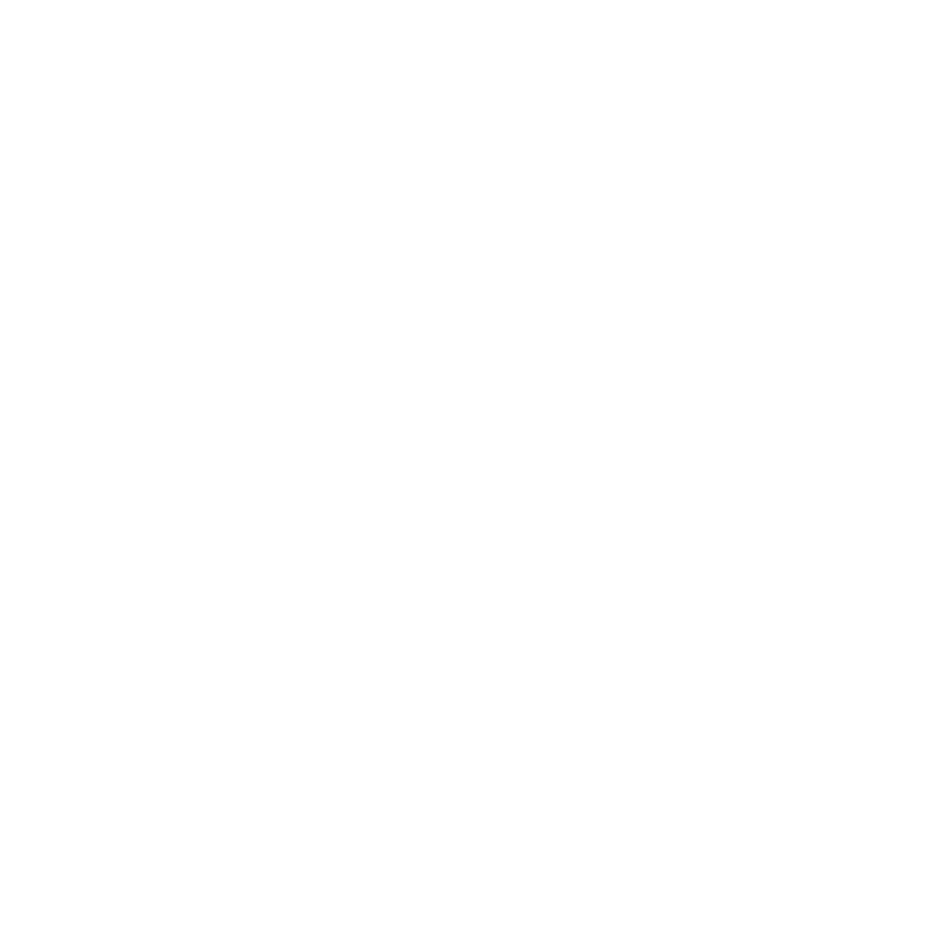

In [40]:
sv.plot_images_grid(images=frame_samples[:4], grid_size=(2, 2))

## roboflow

https://trackers.roboflow.com/develop/learn/track/#trackers

In [54]:
trackers track \
    --source SOURCE_VIDEO_PATH \
    --model rfdetr-nano \
    --tracker sort \
    --display \
    --show-confidence \
    --show-labels \
    --output TARGET_VIDEO_PATH

SyntaxError: invalid syntax (8019708.py, line 1)

In [55]:
import cv2

import supervision as sv
from inference import get_model
from trackers import sort

model = get_model(model)
tracker = sort(
    lost_track_buffer=60,
    minimum_consecutive_frames=5,
)

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.infer(frame)[0]
    detections = sv.Detections.from_inference(result)
    detections = tracker.update(detections)

ImportError: cannot import name 'sort' from 'trackers' (/usr/local/lib/python3.12/dist-packages/trackers/__init__.py)

In [21]:
import cv2
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

# load YOLO
model = model

# DeepSORT
tracker = DeepSort(max_age=30)

cap = cv2.VideoCapture("video.mp4")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for box in results.boxes.data:

        x1, y1, x2, y2, conf, cls = box

        if conf > 0.5:

            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        track_id = track.track_id

        l, t, r, b = track.to_ltrb()

        cv2.rectangle(
            frame,
            (int(l), int(t)),
            (int(r), int(b)),
            (0,255,0),
            2
        )

        cv2.putText(
            frame,
            f"ID {track_id}",
            (int(l), int(t)-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    cv2.imshow("Tracking", frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()

# Analisis BB

## thresholding

In [23]:
from ultralytics import YOLO
import cv2

results = model(SOURCE_VIDEO_PATH)

for r in results:
    boxes = r.boxes

    for box in boxes:

        # koordinat xyxy
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        # width dan height
        width = x2 - x1
        height = y2 - y1

        # confidence
        conf = box.conf[0].item()

        # class
        cls = box.cls[0].item()

        print("Bounding Box:")
        print("x1:", x1)
        print("y1:", y1)
        print("x2:", x2)
        print("y2:", y2)
        print("Width:", width)
        print("Height:", height)
        print("Confidence:", conf)
        print("Class:", cls)
        print("------------")

Streaming output truncated to the last 5000 lines.
Bounding Box:
x1: 411.05950927734375
y1: 901.105224609375
x2: 499.14385986328125
y2: 977.9067993164062
Width: 88.0843505859375
Height: 76.80157470703125
Confidence: 0.8137757778167725
Class: 1.0
------------
Bounding Box:
x1: 604.2138061523438
y1: 354.211669921875
x2: 668.2560424804688
y2: 394.8064270019531
Width: 64.042236328125
Height: 40.594757080078125
Confidence: 0.6101405024528503
Class: 0.0
------------
Bounding Box:
x1: 637.9063720703125
y1: 28.055923461914062
x2: 663.8662109375
y2: 67.31774139404297
Width: 25.9598388671875
Height: 39.261817932128906
Confidence: 0.5601483583450317
Class: 0.0
------------
Bounding Box:
x1: 1903.648681640625
y1: 274.3585510253906
x2: 1918.36669921875
y2: 317.06158447265625
Width: 14.718017578125
Height: 42.703033447265625
Confidence: 0.5510726571083069
Class: 0.0
------------
Bounding Box:
x1: 525.7307739257812
y1: 280.9827575683594
x2: 560.3480224609375
y2: 328.9303894042969
Width: 34.6172485351

In [25]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

results = model(SOURCE_VIDEO_PATH, stream=True)

widths = []
heights = []
frames = []

frame_id = 0

for r in results:

    boxes = r.boxes

    for box in boxes:

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        width = x2 - x1
        height = y2 - y1

        widths.append(width)
        heights.append(height)
        frames.append(frame_id)

    frame_id += 1

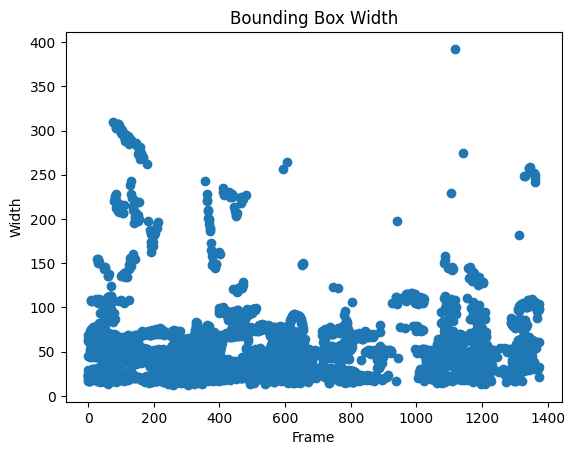

In [26]:
plt.figure()
plt.scatter(frames, widths)

plt.title("Bounding Box Width")
plt.xlabel("Frame")
plt.ylabel("Width")

plt.show()

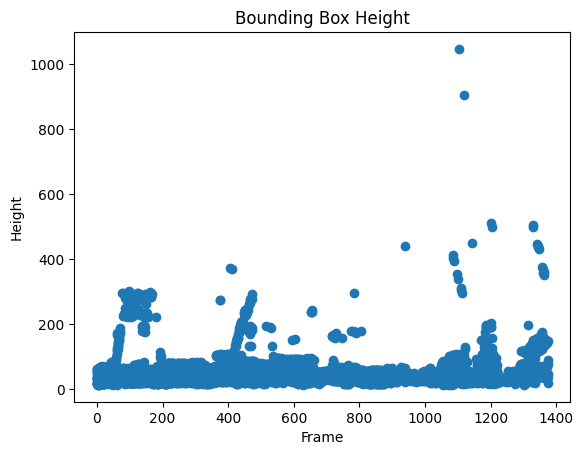

In [27]:
plt.figure()
plt.scatter(frames, heights)

plt.title("Bounding Box Height")
plt.xlabel("Frame")
plt.ylabel("Height")

plt.show()

In [28]:
import numpy as np

width_mean = np.mean(widths)
width_std = np.std(widths)

height_mean = np.mean(heights)
height_std = np.std(heights)

print("Width Mean:", width_mean)
print("Width Std:", width_std)

print("Height Mean:", height_mean)
print("Height Std:", height_std)

Width Mean: 51.4193404695877
Width Std: 37.900020478486546
Height Mean: 52.583864267040695
Height Std: 44.84611703582177


In [29]:
import pandas as pd

df = pd.DataFrame({
    "frame": frames,
    "width": widths,
    "height": heights
})

print(df.describe())

             frame        width       height
count  7282.000000  7282.000000  7282.000000
mean    582.632656    51.419340    52.583864
std     400.774585    37.902623    44.849197
min       0.000000    12.483154    12.313110
25%     259.000000    28.774963    29.527935
50%     494.000000    42.844727    42.172241
75%     899.000000    61.704568    60.884125
max    1374.000000   392.202393  1046.507996


**Width**
* kecil  < 28
* sedang 28 - 61
* besar  > 61

**Height**
* kecil  < 29
* sedang 29 - 60
* besar  > 60

In [30]:
df["area"] = df["width"] * df["height"]

df["area"].describe()

,area
count,7282.000000
mean,3916.318053
std,10477.680180
min,184.305604
25%,925.397067
50%,1781.833140
75%,3555.940763
max,355420.276238


**Area**
* kecil < 925
* medium 925-3555
* large > 3555

In [31]:
df["area"] = df["width"] * df["height"]

q1 = df["area"].quantile(0.25)
q3 = df["area"].quantile(0.75)

def size_category(area):

    if area < q1:
        return "small"

    elif area <= q3:
        return "medium"

    else:
        return "large"

df["size"] = df["area"].apply(size_category)

print(df["size"].value_counts())

size
medium    3640
large     1821
small     1821
Name: count, dtype: int64


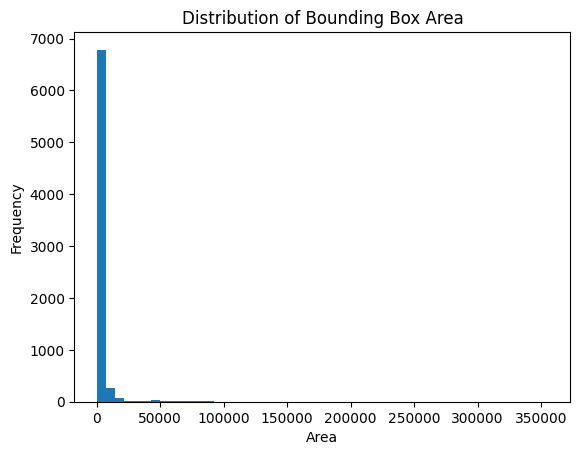

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["area"], bins=50)

plt.title("Distribution of Bounding Box Area")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

In [33]:
# hitung outlier

Q1 = df["area"].quantile(0.25)
Q3 = df["area"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 925.3970670634881
Q3: 3555.9407634381205
IQR: 2630.5436963746324
Lower Bound: -3020.4184774984606
Upper Bound: 7501.756308000069


Menggunakan metode IQR, didapatkan outlier-nya adalah 7500

In [34]:
# eliminasi outlier

Q1 = df["area"].quantile(0.25)
Q3 = df["area"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 925.3970670634881
Q3: 3555.9407634381205
IQR: 2630.5436963746324
Lower Bound: -3020.4184774984606
Upper Bound: 7501.756308000069


In [35]:
df_clean = df[df["area"] <= upper_bound]

In [36]:
print("Data sebelum:", len(df))
print("Data setelah:", len(df_clean))

Data sebelum: 7282
Data setelah: 6801


In [37]:
df_clean["area"].describe()

,area
count,6801.000000
mean,2180.356500
std,1634.663228
min,184.305604
25%,880.554704
50%,1601.392969
75%,3143.215141
max,7500.584142


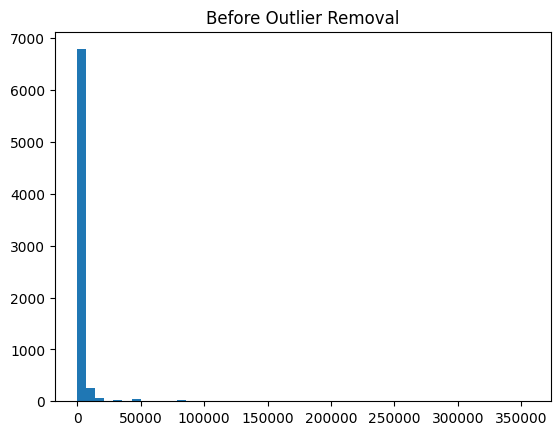

In [38]:
plt.figure()
plt.hist(df["area"], bins=50)
plt.title("Before Outlier Removal")
plt.show()

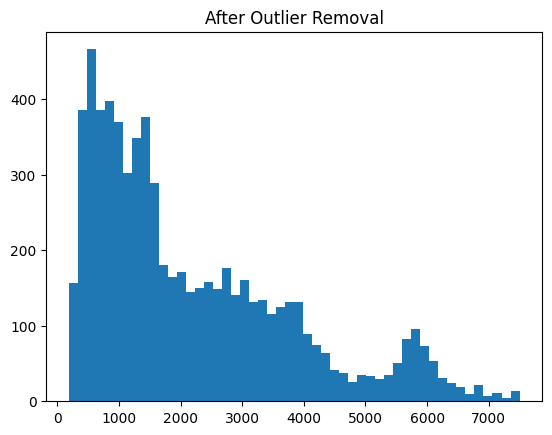

In [39]:
plt.figure()
plt.hist(df_clean["area"], bins=50)
plt.title("After Outlier Removal")
plt.show()

#